In [1]:
import time
import cProfile
import pstats

In [2]:
from RamanModel import *
from HelperFunctions import *
from Plots import *
from lmfit import Model, Parameters
from numba import njit

In [3]:
@njit(fastmath=True)
def add_lorentzian(curve, x, x0, gamma, maximum):
    gamma_sq = gamma * gamma

    for i in range(len(x)):
        dx = x[i] - x0
        curve[i] += (maximum * gamma_sq) / (gamma_sq + dx * dx)

@njit(fastmath=True)
def normalize_curve(curve):
    top = np.max(curve)
    if top > 0:
        curve /= top

@njit(fastmath=True)
def preallocate_centers(array, samples, num_peaks, probs, x_range):
    for sample_idx in range(samples):
        for peak_idx in range(num_peaks):
            array[sample_idx, peak_idx] = position_probability_map(probs, x_range)

def knnFit_persistent(samples, base_parameters, target_x, target_y, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)
    

    #######################################################
    #################### FIRST PASS #######################
    #######################################################
    #print("Round 1 - Exploring with probability map")
    """
    current_y = np.empty_like(target_x)
    for i in range(samples): #THIS LOOKS SO UGLY BLEACH MY EYES
            #current_y = np.zeros(len(target_x))
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]
                #position_interval = position_probability_map(probs, x_range)
                #c = np.random.uniform(position_interval[0], position_interval[1])
                c = position_probability_map(probs, x_range)
                a = np.random.uniform(p["amplitude_range"][0], p["amplitude_range"][1])
                g = np.random.uniform(p["gamma_range"][0], p["gamma_range"][1])

                #current_y += lorentzian(target_x, c, g, a)
                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})
            
            max_point = np.max(current_y)
            if max_point > 0:
                current_y /= max_point

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, current_params))
    """

    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS

        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            centers[:, i] = np.random.uniform(
                p["center_range"][0],
                p["center_range"][1],
                size=samples
            )
        
            amps[:, i] = np.random.uniform(
                p["amplitude_range"][0],
                p["amplitude_range"][1],
                size=samples
            )
        
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        # START LOOP
        for sample_idx in range(samples):
            #current_y = np.zeros(len(target_x))
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]

                if (r == 0):
                    #c = position_probability_map(probs, x_range)
                    c = first_round_centers[sample_idx, i]
                else:
                    c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                #current_y += lorentzian(target_x, c, g, a)
                #add_lorentzian(current_y, target_x, c, g, a)
                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            """
            max_point = np.max(current_y)
            if max_point > 0:
                current_y /= max_point
            """
            normalize_curve(current_y)

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                #heapq.heappush(heap, (-dist, current_params))
                heapq.heappush(heap, (-dist, sample_idx, current_params))
            else:
                if -dist > heap[0][0]:
                    #heapq.heapreplace(heap, (-dist, current_params))
                    heapq.heapreplace(heap, (-dist, sample_idx, current_params))
                    
        # --- DBSCAN-Style Clustering with Origin Tracking ---
        #nearest_neighbors = [item[1] for item in heap]
        nearest_neighbors = [item[2] for item in heap]

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # CRITICAL CHECK: Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                # Mark peaks in this cluster as visited
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

            #print(f"Round {r+2}: Peak {p_idx} search space narrowed (Agreed by {len(curves_in_cluster)} unique curves)")

        #best_neighbor_params = nearest_neighbors[0]
        best_neighbor_params = max(heap, key=lambda x: x[0])[2]
        #print(f"Round {r+2} Best Distance: {-heap[0][0]:.4f}")

    return best_neighbor_params, nearest_neighbors

In [98]:
from numba import njit
import numpy as np

@njit(fastmath=True)
def preallocate_centers(array, samples, num_peaks, probs, x_range):
    for sample_idx in range(samples):
        for peak_idx in range(num_peaks):
            array[sample_idx, peak_idx] = position_probability_map(probs, x_range)

@njit(fastmath=True)
def build_curves_batch(x, centers, gammas, amps):
        """
        centers : (samples, peaks)
        gammas  : (samples, peaks)
        amps    : (samples, peaks)
    
        returns:
            curves : (samples, len(x))
        """
    
        n_samples = centers.shape[0]
        n_peaks   = centers.shape[1]
        n_x       = len(x)
    
        curves = np.zeros((n_samples, n_x))
    
        for s in range(n_samples):
            for p in range(n_peaks):
                c = centers[s, p]
                g = gammas[s, p]
                a = amps[s, p]
                g2 = g * g
                for i in range(n_x):
                    dx = x[i] - c
                    curves[s, i] += (a * g2)/(g2 + dx * dx)
    
        return curves

@njit(fastmath=True)
def normalize_curves_batch(curves):

    n_samples = curves.shape[0]

    for s in range(n_samples):

        m = 0.0

        for i in range(curves.shape[1]):
            if curves[s, i] > m:
                m = curves[s, i]

        if m > 0.0:

            inv = 1.0 / m

            for i in range(curves.shape[1]):
                curves[s, i] *= inv

@njit(fastmath=True)
def batch_distances(curves, target):
    n_samples = curves.shape[0]
    n_x = curves.shape[1]
    distances = np.empty(n_samples)
    for s in range(n_samples):
        acc = 0.0
        for i in range(n_x):
            d = curves[s, i] - target[i]
            acc += d * d
        distances[s] = np.sqrt(acc)
    return distances

def knnFit_persistent(samples, base_parameters, target_x, target_y, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)
    

    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS

        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            centers[:, i] = np.random.uniform(
                p["center_range"][0],
                p["center_range"][1],
                size=samples
            )
        
            amps[:, i] = np.random.uniform(
                p["amplitude_range"][0],
                p["amplitude_range"][1],
                size=samples
            )
        
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        if r == 0:
            centers_to_use = first_round_centers
        else:
            centers_to_use = centers

        curves = build_curves_batch(target_x, centers_to_use, gammas, amps)
        normalize_curves_batch(curves)
        distances = batch_distances(curves, target_y)

        for sample_idx in range(samples):
            dist = distances[sample_idx]
            current_params = []
            for p in range(num_peaks):
                current_params.append({
                    "center": centers_to_use[sample_idx, p],
                    "amplitude": amps[sample_idx, p],
                    "gamma": gammas[sample_idx, p]
                })
        
            if len(heap) < k:
                heapq.heappush(
                    heap,
                    (-dist, sample_idx, current_params)
                )
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(
                        heap,
                        (-dist, sample_idx, current_params)
                    )
                    
        # --- DBSCAN-Style Clustering with Origin Tracking ---
        #nearest_neighbors = [item[1] for item in heap]
        nearest_neighbors = [item[2] for item in heap]

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # CRITICAL CHECK: Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                for idx in cluster_indices:
                    visited[idx] = True

        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

        best_neighbor_params = max(heap, key=lambda x: x[0])[2]

    return best_neighbor_params, nearest_neighbors

In [165]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- 1. Generate the "Target" Curve ---
parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1.0),
    "gamma_range": (0.01, 0.05),
    "x_min": 0,
    "x_max": 1
}

# Generate a target with 4 peaks and some noise
target_x, target_y, target_params = generateCurve(parameters, 4, 1000, 0.1)
target_y = downsample_and_normalize(target_y, resolution=1000)

In [168]:
t0 = time.perf_counter()

best_params, neighbors_params = knnFit_persistent(
    samples=5000,
    base_parameters=parameters,
    target_x=target_x,
    target_y=target_y,
    num_peaks=4,
    k=5,
    rounds=5,
    eps=0.15
)

t1 = time.perf_counter()
print(f'Execution time: {(t1 - t0)*1000}ms')

Execution time: 334.9250005558133ms


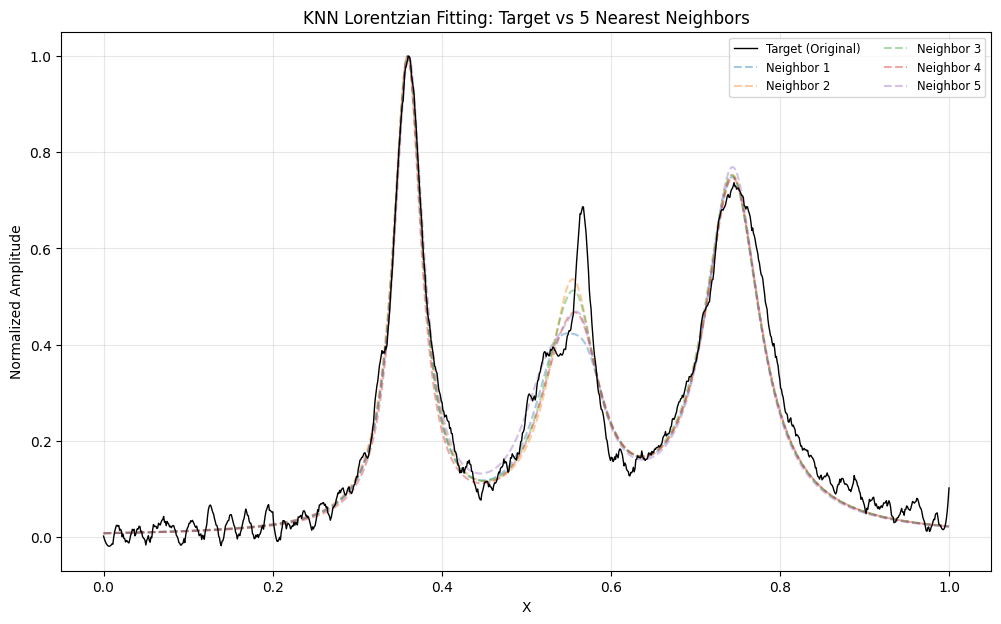

In [169]:
PlotNeighbors(best_params, neighbors_params, target_x, target_y_f)